In [1]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import polars as pl
import numpy as np
import os

In [2]:
plt.rcParams["pdf.fonttype"] = 42  # Use TrueType fonts instead of Type 3 fonts
plt.rcParams["ps.fonttype"] = 42  # For PostScript as well, if needed

# Regions and variant summary statistics

### Summaries

In [3]:
regions_t2t = pd.read_csv('../4_regions/regions_2_lifted.tsv', sep='\t')
print(f'Rows: {regions_t2t.shape[0]}')
regions_t2t.sample(3)

Rows: 157


,chr,left_hs1,right_hs1,lead_hs1,rs_lead,lift_success,1kg,nearest_gene
44,chr10,120547488,120550488,120548988,rs144814361,True,True,BAG3
96,chr6,32419666,32473266,32432921,rs2647066,True,True,HLA-DRB1
87,chr17,15870106,16163455,15993786,rs2078050,True,True,NCOR1


In [4]:
donor_variants = pl.read_csv('../3_variants/donor_subset.tsv', separator='\t')
donor_variants = donor_variants.with_columns((pl.col('chr') + pl.Series(['_']*len(donor_variants)) +
                             pl.col('T2T').cast(pl.String) + pl.Series(['_']*len(donor_variants)) + 
                             pl.col('ref') + pl.Series(['_']*len(donor_variants)) + 
                             pl.col('alt')).alias('variant_id_hs1'))
print(f'Rows: {donor_variants.shape[0]}')
donor_variants.sample(3)

Rows: 168647


chr,T2T,ref,alt,start,stop,lead,rs_lead,lift_success,in_1kg,nearest_gene,variant_id_hs1
str,i64,str,str,i64,i64,i64,str,bool,bool,str,str
"""chr3""",17704084,"""Ct""","""C,CTt""",17282357,17818971,17712603,"""rs144678625""",true,true,"""TBC1D5""","""chr3_17704084_Ct_C,CTt"""
"""chr6""",133962289,"""T""","""C""",133961420,134153393,134023933,"""rs146617529""",true,true,"""RPS12""","""chr6_133962289_T_C"""
"""chr1""",52608429,"""C""","""CT""",52575966,52754589,52606191,"""rs377808""",true,true,"""ZYG11B""","""chr1_52608429_C_CT"""


In [5]:
counts = donor_variants.group_by('rs_lead').agg(
    pl.col('T2T').count())

In [6]:
print(f'Donor EVs in regions: {donor_variants.shape[0]} / 7 million')
print(f'Most amount of donor variants in one region: {np.max(list(counts["T2T"]))}')
print(f'Least amount of donor variants in one region: {np.min(list(counts["T2T"]))}')
print(f'Mean amount of donor variants in one region: {int(np.round(np.mean(list(counts["T2T"]))))}')

Donor EVs in regions: 168647 / 7 million
Most amount of donor variants in one region: 13931
Least amount of donor variants in one region: 8
Mean amount of donor variants in one region: 1074


In [7]:
regions_t2t['size'] = regions_t2t['right_hs1'] - regions_t2t['left_hs1']

In [8]:
print(f'Absolute genomic coverage of all regions combined: {np.round(np.sum(regions_t2t["size"])/100_000)/10} Mbp / 3.1 Gbp')
print(f'Relative genomic coverage of all regions combined: {np.round(100_000*np.sum(regions_t2t["size"])/3_100_000_000)/1000}%')

Absolute genomic coverage of all regions combined: 16.7 Mbp / 3.1 Gbp
Relative genomic coverage of all regions combined: 0.538%


In [9]:
print(f'Regions which (rs) lead is in 1kg: {regions_t2t[regions_t2t["1kg"] == True].shape[0]}/{regions_t2t.shape[0]}')
print(f'Regions with minimal size (3kbp): {regions_t2t[regions_t2t["size"] == 3000].shape[0]}/{regions_t2t.shape[0]}')
print(f'Regions succesfully lifted to hs1: {regions_t2t[regions_t2t["lift_success"] == True].shape[0]}/{regions_t2t.shape[0]}')

Regions which (rs) lead is in 1kg: 151/157
Regions with minimal size (3kbp): 18/157
Regions succesfully lifted to hs1: 155/157


### caQTL, ASCA, eQTL, CREsted Significance Filters

**Requires external file with variants filtered**

In [10]:
vars_link = "../../../../Manuscript/Tables/caQTL_ASCA_ISM_filt_with_eQTL_info.csv"

In [11]:
vars_filtered = pl.read_csv(vars_link)
print(f'Rows: {vars_filtered.shape[0]}')
vars_filtered.sample(3)

Rows: 1760401


variant_id,variant_type,peak_id,brain_region,cell_type,diff,logfc,max_percentile,model,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,chr,caQTL_pval_adj_full,TEST.SNP.CHROM,TEST.SNP.POS,TEST.SNP.REF.ALLELE,TEST.SNP.ALT.ALLELE,REGION.START,REGION.END,LOGLIKE.NULL,LOGLIKE.ALT,CHISQ,P.VALUE,ALPHA,BETA,PHI,TOTAL.AS.READ.COUNT,REF.AS.READ.COUNT,ALT.AS.READ.COUNT,TOTAL.READ.COUNT,REF_LEN,ALT_LEN,allelic_imbalance,MAX_ALLELE_LEN,pval_adj,signif_fdr05,indel_bin,signif,pval_adj_full,signif_fdr05_full,ASCA_pval_adj_full,asca_fdr_bin,qtl_fdr_bin,abs_allelic_imbalance,abs_slope,allelic_imbalance_0.1,slope_0.1,effect_size_filt,signif_ASCA,signif_caQTL,signif_caQTL_ASCA,signif_caQTL_or_ASCA,signif_caQTL_or_ASCA_fdr001,signif_caQTL_ASCA_no_effect_size_filter,cell_type_corrected,phenotype_id,start_distance_eqtl,end_distance_eqtl,af_eqtl,ma_samples_eqtl,ma_count_eqtl,pval_nominal_eqtl,slope_eqtl,slope_se_eqtl,variant_type_eqtl,ct_reg,signif_eqtl,p_adj
str,str,str,str,str,f64,f64,f64,str,i64,i64,f64,i64,i64,f64,f64,f64,str,f64,str,i64,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,bool,str,str,f64,bool,f64,str,str,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,i64,i64,f64,i64,i64,f64,f64,f64,str,str,bool,f64
"""chr3_63668990_C_T""","""SNP""","""chr3:63668811-63669311""","""SN""","""Oligo""",-0.000701,-0.032317,55.5965,"""sn_deepPeak_mean_finetuned""",178,-321,0.392593,81,106,2.7931e-9,0.201451,0.030602,"""chr3""",0.000002,"""chr3""",63668990,"""C""","""T""",63668811,63669311,-505.73,-460.69,90.071,0.0,0.197061,0.679726,0.001192,966,203,763,0,1,1,0.275246,1,0.0,true,"""SNP""","""pval < e-5""",0.0,true,0.0,"""<0.01""","""<0.01""",0.275246,0.201451,true,true,true,true,true,true,true,true,true,"""Oligo""","""THOC7""",-208508,-239102,0.376068,69,88,0.090093,-0.052042,0.030422,"""snp""","""Oligo, SN""",false,1.0
"""chr21_43810403_A_T""","""SNP""","""chr21:43810048-43810548""","""SN""","""Oligo""",0.000616,0.021166,81.412,"""sn_deepPeak_mean_finetuned""",354,-145,0.02963,8,8,0.001114,-0.475495,0.1412659,"""chr21""",0.093388,"""chr21""",43810403,"""A""","""T""",43810048,43810548,-242.66,-230.14,25.053,5.5769e-7,0.67026,0.23528,0.001185,528,439,89,0,1,1,-0.240177,1,0.000028,true,"""SNP""","""pval < e-5""",0.000043,true,0.000046,"""<0.01""","""0.01-0.1""",0.240177,0.475495,true,true,true,true,true,true,true,true,true,"""Oligo""","""LRRC3""",994439,987754,0.025641,6,6,0.895386,-0.013053,0.099026,"""snp""","""Oligo, SN""",false,1.0
"""chr3_132076709_C_T""","""SNP""","""chr3:132076465-132076965""","""CC""","""Sst""",-0.002588,-0.025755,88.585,"""cc_deepPeak_mean_finetuned""",243,-256,0.193939,56,64,0.000552,0.2399478,0.067619,"""chr3""",0.057288,"""chr3""",132076709,"""C""","""T""",132076465,132076965,-59.09,-51.81,14.565,0.000135,0.220963,0.673295,0.001146,118,27,91,0,1,1,0.252909,1,0.007699,true,"""SNP""","""pval > e-5""",0.005134,true,0.005627,"""<0.01""","""0.01-0.1""",0.252909,0.2399478,true,true,true,true,true,true,true,true,true,"""Sst""","""EEFSEC""",1181588,908880,0.202381,44,51,0.191105,-0.05132,0.039018,"""snp""","""Sst, CC""",false,1.0


In [12]:
vars_core = vars_filtered[['signif_caQTL_ASCA','logfc','p_adj','variant_id','phenotype_id','cell_type','brain_region','peak_id']].unique()
vars_core.sample(3)

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,peak_id
bool,f64,f64,str,str,str,str,str
true,-0.006546,1.0,"""chr12_9302209_C_T""","""CD69""","""Micro-PVM""","""CC""","""chr12:9301740-9302240"""
true,-0.036278,1.0,"""chr11_5329698_G_GT""","""HBG2""","""L6_CT""","""CC""","""chr11:5329462-5329962"""
true,0.333452,1.0,"""chr5_73996792_G_A""","""BTF3""","""Micro-PVM""","""SN""","""chr5:73996448-73996948"""


In [13]:
# filter for significant caQTL and ASCA alone
vars_ascaqtl = vars_core.filter(pl.col("signif_caQTL_ASCA"))
print('1: ', vars_ascaqtl.shape)

# ascaqtl + crested
vars_crested_ascaqtl = vars_ascaqtl.filter(pl.col('logfc').abs() > 0.2)
print('2: ', vars_crested_ascaqtl.shape)

# ascaqtl + eqtl
vars_ascaqtl_eqtl = vars_ascaqtl.filter(pl.col('p_adj').abs() < 0.05)
print('3: ', vars_ascaqtl_eqtl.shape)

# ascaqtl + eqtl + crested
vars_ascaqtl_eqtl_crested = vars_ascaqtl_eqtl.filter(pl.col('logfc').abs() > 0.2)
print('4: ', vars_ascaqtl_eqtl_crested.shape)

# crested
vars_crested = vars_core.filter(pl.col('logfc').abs() > 0.2)
print('5: ', vars_crested.shape)

# crested + eqtl
vars_crested_eqtl = vars_crested.filter(pl.col('p_adj').abs() < 0.05)
print('6: ', vars_crested_eqtl.shape)

# eqtl
vars_eqtl = vars_core.filter(pl.col('p_adj').abs() < 0.05)
print('7: ', vars_eqtl.shape)

1:  (1659349, 8)
2:  (417149, 8)
3:  (7781, 8)
4:  (1216, 8)
5:  (430133, 8)
6:  (1264, 8)
7:  (8265, 8)


In [14]:
LD_all = vars_filtered.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_a = vars_ascaqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_ac = vars_crested_ascaqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_ae = vars_ascaqtl_eqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_aec = vars_ascaqtl_eqtl_crested.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_c = vars_crested.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_ec = vars_crested_eqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_e = vars_eqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')

In [16]:
LD_aec.write_csv('../3_variants/LD_ASCQA_caQTL_eQTL_CREsted.tsv', separator='\t')

### Amount of regions for certain significance filters FIG 7.A

In [17]:
LD_a_ = LD_a.with_columns(pl.col('signif_caQTL_ASCA').alias('A'))
LD_ac_ = LD_ac.with_columns(pl.col('signif_caQTL_ASCA').alias('B'))
LD_ae_ = LD_ae.with_columns(pl.col('signif_caQTL_ASCA').alias('C'))
LD_aec_ = LD_aec.with_columns(pl.col('signif_caQTL_ASCA').alias('D'))
graph = LD_a_.join(LD_ac_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','B']],
                   on=['variant_id','phenotype_id','cell_type','rs_lead','brain_region'], how='full', coalesce=True).fill_null(False)
graph = graph.join(LD_ae_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','C']],
                   on=['variant_id','phenotype_id','cell_type','rs_lead','brain_region'], how='full', coalesce=True).fill_null(False)
graph = graph.join(LD_aec_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','D']],
                   on=['variant_id','phenotype_id','cell_type','rs_lead','brain_region'], how='full', coalesce=True).fill_null(False)

In [18]:
GWAS_hs1 = pl.read_csv('../2_source/GWAS.hs1.tsv', separator='\t')
print(f'Rows: {GWAS_hs1.shape[0]}')
GWAS_hs1.sample(3)

Rows: 11586362


hs1id,hg38id,chr,hs1,ref,alt,p,logp,sig
str,str,str,i64,str,str,f64,f64,bool
"""chr5_27874259_A_G""","""chr5_27768678_A_G""","""chr5""",27874259,"""A""","""G""",0.3716,0.989937,false
"""chr15_93726301_A_G""","""chr15_95961726_A_G""","""chr15""",93726301,"""A""","""G""",0.4135,0.883098,false
"""chr13_24437230_A_G""","""chr13_25227570_A_G""","""chr13""",24437230,"""A""","""G""",0.3901,0.941352,false


**Variants that are GWAS significant**

In [19]:
abcde = graph.join(GWAS_hs1[['hs1id','sig']], left_on='variant_id', right_on='hs1id', how='left').fill_null(False) #.rename({'sig':'E'})
abcde = abcde.with_columns(((pl.col('sig') == True) & (pl.col('D') == True)).alias('E')).drop(['signif_caQTL_ASCA','sig'])
print(f'Rows: {abcde.shape[0]}')
abcde.sample(3)

Rows: 57084


logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,peak_id,rs_lead,A,B,C,D,E
f64,f64,str,str,str,str,str,str,bool,bool,bool,bool,bool
0.020001,1.0,"""chr17_82859343_C_A""","""MYADML2""","""Oligo""","""CC""","""chr17:82858901-82859401""","""rs8074498""",true,false,false,false,false
-0.031475,2.0957e-31,"""chr17_47012770_G_A""","""ARL17B""","""Pvalb""","""CC""","""chr17:47012674-47013174""","""rs2532384""",true,false,true,false,false
-0.012806,1.0,"""chr17_46680495_T_C""","""MAPT""","""Oligo""","""SN""","""chr17:46680282-46680782""","""rs2532384""",true,false,false,false,false


In [20]:
abcde.write_csv('../5_figs/fig7A.tsv', separator='\t')

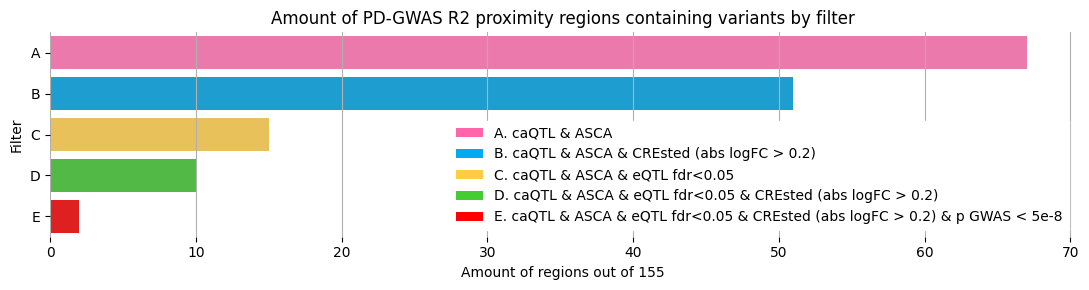

In [21]:
total_regions_possible = regions_t2t[(regions_t2t['lift_success'] == True)].shape[0]
palette=['#f6a','#0ae','#fc4','#4c3','#F00']
fig = plt.figure(figsize=(11,3))
ax = fig.add_subplot(111)
sns.barplot(data=pd.DataFrame({'Filter':[
                                            'A',
                                            'B',
                                            'C',
                                            'D',
                                            'E',
                                        ],
                               '#Regions':[
                                               len(set(abcde.filter(pl.col('A') == True)['rs_lead'])),
                                               len(set(abcde.filter(pl.col('B') == True)['rs_lead'])),
                                               len(set(abcde.filter(pl.col('C') == True)['rs_lead'])),
                                               len(set(abcde.filter(pl.col('D') == True)['rs_lead'])),
                                               len(set(abcde.filter(pl.col('E') == True)['rs_lead'])),
                               ]}),
            x='#Regions', y='Filter', hue='Filter',
            palette=palette)
plt.title('Amount of PD-GWAS R2 proximity regions containing variants by filter')
plt.xlabel(f'Amount of regions out of {total_regions_possible}')
plt.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
legend_elements = [
                    Patch(facecolor=palette[0], label='A. caQTL & ASCA'),
                    Patch(facecolor=palette[1], label='B. caQTL & ASCA & CREsted (abs logFC > 0.2)'),
                    Patch(facecolor=palette[2], label='C. caQTL & ASCA & eQTL fdr<0.05'),
                    Patch(facecolor=palette[3], label='D. caQTL & ASCA & eQTL fdr<0.05 & CREsted (abs logFC > 0.2)'),
                    Patch(facecolor=palette[4], label='E. caQTL & ASCA & eQTL fdr<0.05 & CREsted (abs logFC > 0.2) & p GWAS < 5e-8')]
plt.legend(handles=legend_elements, loc='lower right', frameon=True, fancybox=False, framealpha=1, edgecolor='white').set_zorder(12)
plt.tight_layout()
plt.savefig('../5_figs/fig7A.pdf')
plt.show()

### Amount of regions for certain CREsted filters FIG 7.G

In [22]:
path = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Tables/ISM_model_scores_all_combined.parquet"
RAW = pl.scan_parquet(path).filter(
        pl.col("model").is_in(['cc_deepPeak_mean_finetuned', 'sn_deepPeak_mean_finetuned']),
    ).collect()

In [23]:
CRE02 = RAW.filter(pl.col("logfc").abs() > 0.2)
CRE05 = RAW.filter(pl.col("logfc").abs() > 0.5)
CRE1 = RAW.filter(pl.col("logfc").abs() > 1)

In [24]:
print(len(set(CRE02['variant_id'])))
print(len(set(CRE05['variant_id'])))
print(len(set(CRE1['variant_id'])))

911392
215766
51024


In [25]:
GWAS_hs1 = pl.read_csv('../2_source/GWAS.hs1.tsv', separator='\t')
print(f'Rows: {GWAS_hs1.shape[0]}')
GWAS_hs1.sample(3)

Rows: 11586362


hs1id,hg38id,chr,hs1,ref,alt,p,logp,sig
str,str,str,i64,str,str,f64,f64,bool
"""chr3_144594332_G_A""","""chr3_141847027_G_A""","""chr3""",144594332,"""G""","""A""",0.1153,2.160218,false
"""chr16_17243871_T_C""","""chr16_17236872_T_C""","""chr16""",17243871,"""T""","""C""",0.9749,0.02542,false
"""chr6_151831936_G_T""","""chr6_150631420_G_T""","""chr6""",151831936,"""G""","""T""",0.09346,2.370222,false


In [26]:
CRE02_GWAS = GWAS_hs1.join(CRE02, left_on='hs1id', right_on='variant_id', how='inner', coalesce=False)
CRE05_GWAS = GWAS_hs1.join(CRE05, left_on='hs1id', right_on='variant_id', how='inner', coalesce=False)
CRE1_GWAS = GWAS_hs1.join(CRE1, left_on='hs1id', right_on='variant_id', how='inner', coalesce=False)

In [27]:
print(len(set(CRE02_GWAS['variant_id'])))
print(len(set(CRE05_GWAS['variant_id'])))
print(len(set(CRE1_GWAS['variant_id'])))

391811
91547
21017


In [28]:
CRE02_GWAS_sig = CRE02_GWAS.filter(pl.col('sig'))
CRE05_GWAS_sig = CRE05_GWAS.filter(pl.col('sig'))
CRE1_GWAS_sig = CRE1_GWAS.filter(pl.col('sig'))

In [29]:
print(len(set(CRE02_GWAS_sig['variant_id'])))
print(len(set(CRE05_GWAS_sig['variant_id'])))
print(len(set(CRE1_GWAS_sig['variant_id'])))

685
149
37


In [30]:
CRE02_LD = donor_variants.join(CRE02, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE05_LD = donor_variants.join(CRE05, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE1_LD = donor_variants.join(CRE1, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE02_GWAS_LD = donor_variants.join(CRE02_GWAS, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE05_GWAS_LD = donor_variants.join(CRE05_GWAS, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE1_GWAS_LD = donor_variants.join(CRE1_GWAS, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE02_GWAS_sig_LD = donor_variants.join(CRE02_GWAS_sig, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE05_GWAS_sig_LD = donor_variants.join(CRE05_GWAS_sig, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE1_GWAS_sig_LD = donor_variants.join(CRE1_GWAS_sig, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)

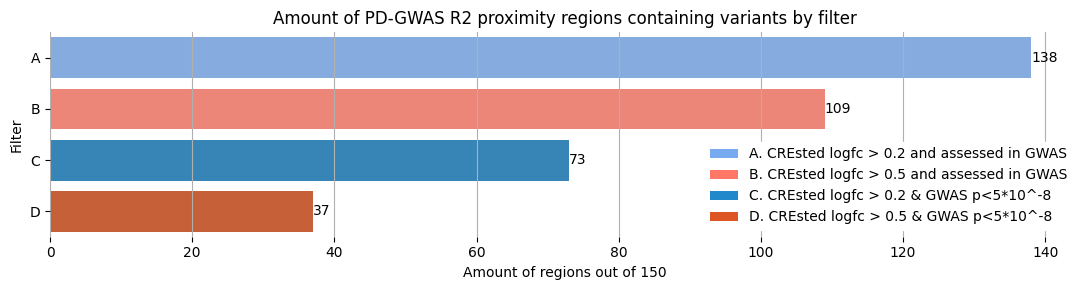

In [31]:
palette=['#7ae','#f76','#28c','#d52']
fig = plt.figure(figsize=(11,3))
ax = sns.barplot(data=pd.DataFrame({'Filter':[
                                            'A',
                                            'B',
                                            'C',
                                            'D',
                                        ],
                               '#Regions':[
                                               len(set(CRE02_GWAS_LD['rs_lead'])),
                                               len(set(CRE05_GWAS_LD['rs_lead'])),
                                               len(set(CRE02_GWAS_sig_LD['rs_lead'])),
                                               len(set(CRE05_GWAS_sig_LD['rs_lead'])),
                               ]}),
            x='#Regions', y='Filter', hue='Filter', palette=palette)
for container in ax.containers:
    ax.bar_label(container)
legend_elements = [
                    Patch(facecolor=palette[0], label='A. CREsted logfc > 0.2 and assessed in GWAS'),
                    Patch(facecolor=palette[1], label='B. CREsted logfc > 0.5 and assessed in GWAS'),
                    Patch(facecolor=palette[2], label='C. CREsted logfc > 0.2 & GWAS p<5*10^-8'),
                    Patch(facecolor=palette[3], label='D. CREsted logfc > 0.5 & GWAS p<5*10^-8')]
plt.legend(handles=legend_elements, loc='lower right', frameon=True, fancybox=False, framealpha=1,
           edgecolor='white').set_zorder(12)
plt.title('Amount of PD-GWAS R2 proximity regions containing variants by filter')
plt.xlabel(f'Amount of regions out of {150}')
plt.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.savefig('../5_figs/fig7G.pdf')
plt.show()